Simulate the default behavior of a homogeneous portfolio of
1000 obligors, each with an unconditional default probability of
1%. We consider dependent defaults with default correlation
0.5%. Dependence is introduced through a common random
default probability:


P ∼Beta(𝛼, 𝛽),

Yi | P ∼ Bernoulli(P).

Simulate this model 2000 times and visualize the distribution of the number of defaults using a histogram.


Parameters:
N = 2000, np.random.seed(42).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
#parameters
N = 2000                    #number of simulations
n_obligors = 1000           #number of obligors
p = 0.01                    #each oblig with unconditional POD of 1%
rho = 0.005                 #default dependence btw obligor / correlation btw. defaults

In [4]:
#calculate alpha and beta for the Beta distribution

s = 1 / rho - 1
alpha = p * s
beta = (1 - p) * s

print(f"alpha = {alpha:}, beta = {beta:}")

### s ist der Konzentrationsparameter bzw. precision. Er steuert in der Verteilung, wie stark die gemeinsame Ausfallrate P um ihren Erwartungswert streut###




alpha = 1.99, beta = 197.01


Intuition: Was steuert s?

rho klein       s groß      Beta-Verteilung schmal → P bleibt nah an p → wenig systemisches Risiko

rho groß        s klein     Beta-Verteilung breit → P kann weit von p abweichen → viel systemisches Risiko

In [5]:
#Monte Carlo Simulation with N = 2000

defaults = []

for _ in range(N):
    P = np.random.beta(alpha, beta)

    Y = np.random.binomial(1, P, size=n_obligors)

    defaults.append(np.sum(Y))

defaults = np.array(defaults)

values, counts = np.unique(defaults, return_counts=True)

pmf = counts / N

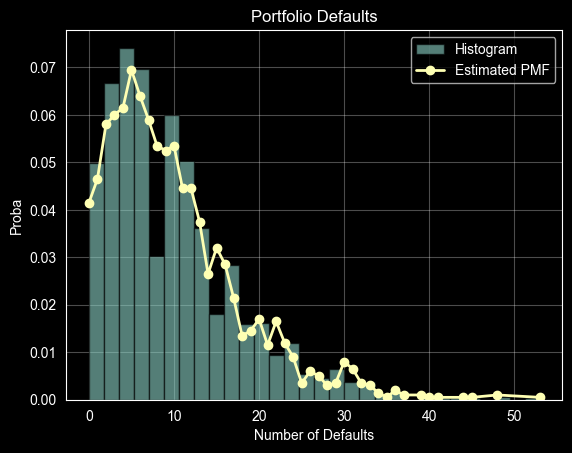

In [6]:
# Histogram
plt.hist(defaults,
         bins=30,
         density=True,
         alpha=0.6,
         edgecolor='black',
         label='Histogram')
# PMF
plt.plot(values,
         pmf,
         'o-',
         linewidth=2,
         label='Estimated PMF')

plt.xlabel("Number of Defaults")
plt.ylabel("Proba")
plt.title("Portfolio Defaults")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()